In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Japan Image Pattern Detection

## Images used

- Torii Gates https://bokksu.com/blogs/news/unlocking-the-meaning-of-japanese-religious-symbols-torii-gates-shrines-and-more?srsltid=AfmBOorejmq72H82tLwRkZgv5nzx69tsLRP8lQnf-rehWj4I4E_wgwqN

## Helpers

In [2]:
def show(img, title="", cmap="gray"):
    plt.figure(figsize=(4,4))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

In [3]:
def show_pair(a, b, titles=("Original", "Processed"), figsize=(10,5), cmap='gray'):
    plt.figure(figsize=figsize)

    # left
    plt.subplot(1,2,1)
    if a.ndim == 2:
        plt.imshow(a, cmap=cmap)
    else:
        plt.imshow(a)
    plt.title(titles[0])
    plt.axis('off')

    # right
    plt.subplot(1,2,2)
    if b.ndim == 2:
        plt.imshow(b, cmap=cmap)
    else:
        plt.imshow(b)
    plt.title(titles[1])
    plt.axis('off')

    plt.show()

In [4]:
def load_rgb(path: str, dummy: bool=False, size: tuple[int,int]=(720,1080)) -> np.ndarray:
    if os.path.exists(path) and not dummy:
        img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            dummy = True
        else:
            return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # dummy: colorful gradient + noise
    h, w = size
    y = np.linspace(0, 1, h)[:,None]
    x = np.linspace(0, 1, w)[None,:]
    r = x
    g = y
    b = 1 - 0.5*(x+y)
    img = np.stack([r,g,b], axis=2)
    img += 0.05*np.random.RandomState(42).randn(h,w,3)
    img = np.clip(img, 0, 1)
    return (img*255).astype(np.uint8)

In [5]:
def save_rgb(path: str, img_rgb: np.ndarray):
    bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(path, bgr)

## Day 5

### Sample Image

In [6]:
def create_sample_image(size=(256, 256)) -> np.ndarray:
    H, W = size
    img = np.zeros((H, W, 3), np.uint8) + 255  # white background

    # rectangle
    cv2.rectangle(img, (30, 30), (120, 120), (0, 0, 0), 2)

    # circle
    cv2.circle(img, (190, 70), 40, (0, 0, 0), 2)

    # diagonal line
    cv2.line(img, (30, 200), (220, 140), (0, 0, 0), 2)

    # text
    cv2.putText(img, "JP", (140, 210),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2, cv2.LINE_AA)

    return img

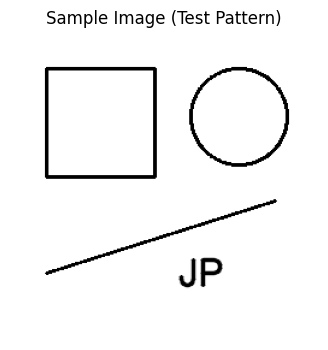

In [7]:
img_rgb = create_sample_image()
show(img_rgb, "Sample Image (Test Pattern)")

### Canny Edge Detector

#### Grayscale and Gaussian Blur

In [8]:
def to_gray(rgb: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

def gaussian_blur(gray: np.ndarray,
                  ksize=(5,5),
                  sigma=1.4) -> np.ndarray:
    return cv2.GaussianBlur(gray, ksize, sigmaX=sigma)

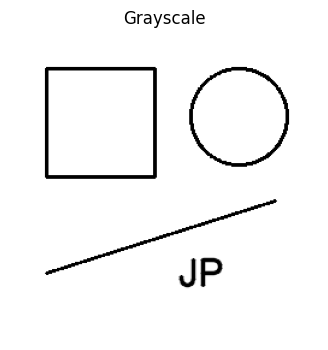

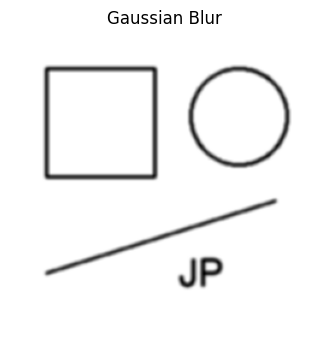

In [9]:
gray = to_gray(img_rgb)
blur = gaussian_blur(gray)

show(gray, "Grayscale")
show(blur, "Gaussian Blur")

#### Sobel Gradients

In [10]:
def sobel_gradients(blur: np.ndarray):
    Gx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.hypot(Gx, Gy)
    direction = np.arctan2(Gy, Gx)  # radians
    return Gx, Gy, magnitude, direction

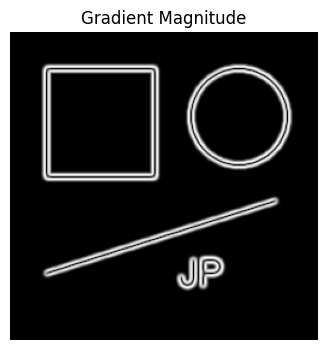

In [11]:
Gx, Gy, mag, direction = sobel_gradients(blur)
mag_disp = (mag / (mag.max() + 1e-8) * 255).astype(np.uint8)

show(mag_disp, "Gradient Magnitude")

#### Non-Maximum Suppression

In [12]:
def non_max_suppression(magnitude: np.ndarray,
                        direction: np.ndarray) -> np.ndarray:
    angle = np.degrees(direction)
    angle[angle < 0] += 180

    H, W = magnitude.shape
    Z = np.zeros_like(magnitude, dtype=np.float64)

    for i in range(1, H-1):
        for j in range(1, W-1):
            q = 0.0
            r = 0.0

            # Angle 0°
            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = magnitude[i, j+1]
                r = magnitude[i, j-1]
            # Angle 45°
            elif 22.5 <= angle[i, j] < 67.5:
                q = magnitude[i+1, j-1]
                r = magnitude[i-1, j+1]
            # Angle 90°
            elif 67.5 <= angle[i, j] < 112.5:
                q = magnitude[i+1, j]
                r = magnitude[i-1, j]
            # Angle 135°
            elif 112.5 <= angle[i, j] < 157.5:
                q = magnitude[i-1, j-1]
                r = magnitude[i+1, j+1]

            if magnitude[i, j] >= q and magnitude[i, j] >= r:
                Z[i, j] = magnitude[i, j]
            else:
                Z[i, j] = 0.0

    return Z

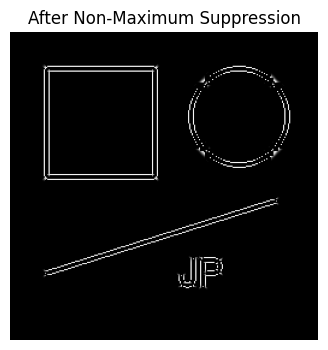

In [13]:
nms = non_max_suppression(mag, direction)
nms_disp = (nms / (nms.max() + 1e-8) * 255).astype(np.uint8)

show(nms_disp, "After Non-Maximum Suppression")

#### Double Threshold

In [14]:
def double_threshold(nms: np.ndarray,
                     high_ratio=0.15,
                     low_ratio=0.05):
    high = nms.max() * high_ratio
    low  = high * low_ratio

    strong_val = 255
    weak_val   = 75

    res = np.zeros_like(nms, dtype=np.uint8)

    strong_i, strong_j = np.where(nms >= high)
    weak_i, weak_j     = np.where((nms <= high) & (nms >= low))

    res[strong_i, strong_j] = strong_val
    res[weak_i, weak_j]     = weak_val

    return res, weak_val, strong_val

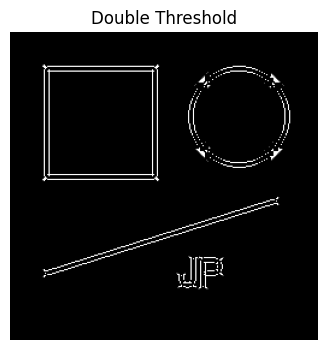

In [15]:
dt, weak_val, strong_val = double_threshold(nms, high_ratio=0.15, low_ratio=0.05)

show(dt, "Double Threshold")

#### Hysteresis

In [16]:
def hysteresis(img: np.ndarray,
               weak_val=75,
               strong_val=255) -> np.ndarray:
    H, W = img.shape
    out = img.copy()

    for i in range(1, H-1):
        for j in range(1, W-1):
            if out[i, j] == weak_val:
                # If any neighbour is strong, keep it, otherwise discard
                if np.any(out[i-1:i+2, j-1:j+2] == strong_val):
                    out[i, j] = strong_val
                else:
                    out[i, j] = 0
    return out

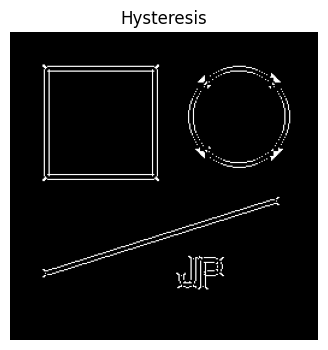

In [17]:
edges = hysteresis(dt, weak_val, strong_val)

show(edges, "Hysteresis")

#### Full Canny Pipeline

In [18]:
def canny_manual(rgb: np.ndarray,
                 blur_ksize=(5,5),
                 blur_sigma=1.4,
                 high_ratio=0.15,
                 low_ratio=0.05) -> np.ndarray:
    gray = to_gray(rgb)
    blur = gaussian_blur(gray, blur_ksize, blur_sigma)
    Gx, Gy, mag, direction = sobel_gradients(blur)
    nms = non_max_suppression(mag, direction)
    dt, weak_val, strong_val = double_threshold(nms, high_ratio, low_ratio)
    edges = hysteresis(dt, weak_val, strong_val)
    return edges

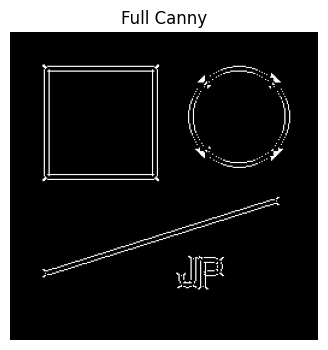

In [19]:
edges2 = canny_manual(img_rgb)

show(edges2, "Full Canny")

## Day 6

### Use Case (Japan)
Detect the **structural edges** of a Japanese **torii gate corridor** and turn the photo into a clean, line-drawing–like edge map using a classic (non-ML) algorithm.


### Problem
Real photos of torii corridors contain mixed lighting, shadows, textures (wood, foliage, stone) and background clutter.
We want a **geometry-focused edge map** that keeps the main gate and path contours while suppressing small, noisy details.


### How (Methods)

- Convert the RGB torii image to **grayscale** and apply **Gaussian blur** for noise reduction.
- Compute **Sobel gradients** to obtain gradient magnitude and direction.
- Apply **non-maximum suppression** to thin edges along the local gradient direction.
- Use **double thresholding** to label strong vs. weak edge responses.
- Perform **hysteresis** to keep only weak edges connected to strong ones → final Canny edge map.


### Why (Rationale)

- Torii corridors have **strong, high-contrast vertical and horizontal lines**, which are ideal for edge-based structure extraction.
- The **Canny edge detector** is a classic, interpretable algorithm with clear sub-steps, matching the assignment requirement.
- Separating blur, gradients, NMS, thresholds, and hysteresis lets us **tune each stage** and visually inspect its effect on the Japanese scene.


### What (Scope)

1. **Torii Corridor (Original)** – load and display the RGB photo.
2. **Intermediate Stages** – show grayscale, blurred image, gradient magnitude, and NMS result.
3. **Final Edge Map** – binary Canny edge image of the torii corridor, used as a clean structural representation of the Japanese scene.


## Day 7

### Canny Edge Detector (Japan Image)

In [20]:
TORII_PATH = "Data/Torii_Gates.png"
img_torii = load_rgb(TORII_PATH)

save_rgb('images/torii.jpg', img_torii)

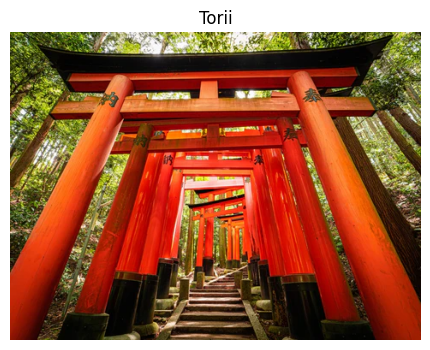

In [21]:
plt.figure(figsize=(6,4)); plt.imshow(img_torii); plt.title("Torii"); plt.axis("off"); plt.show()

#### Grayscale

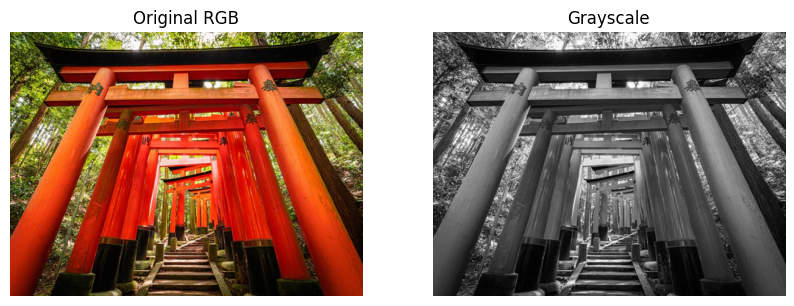

In [22]:
gray = to_gray(img_torii)

save_rgb("outputs/torii_step1_gray.png", gray)
show_pair(img_torii, gray, titles=("Original RGB", "Grayscale"))

#### Gaussian Blur

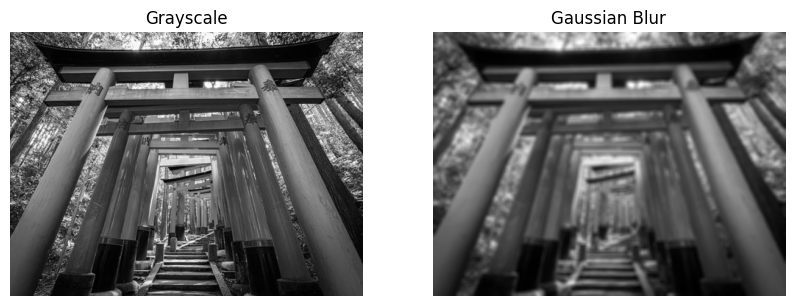

In [23]:
blur = gaussian_blur(gray, ksize=(7,7), sigma=3)

save_rgb("outputs/torii_step2_blur.png", blur)
show_pair(gray, blur, titles=("Grayscale", "Gaussian Blur"))

#### Sobel Gradients

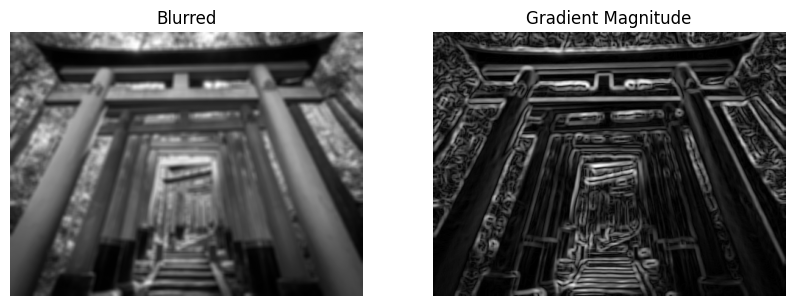

In [24]:
Gx, Gy, mag, direction = sobel_gradients(blur)
mag_disp = (mag / (mag.max() + 1e-8) * 255).astype(np.uint8)

save_rgb("outputs/torii_step3_grad_mag.png", mag_disp)
show_pair(blur, mag_disp, titles=("Blurred", "Gradient Magnitude"))

#### Non-Maximum Suppression

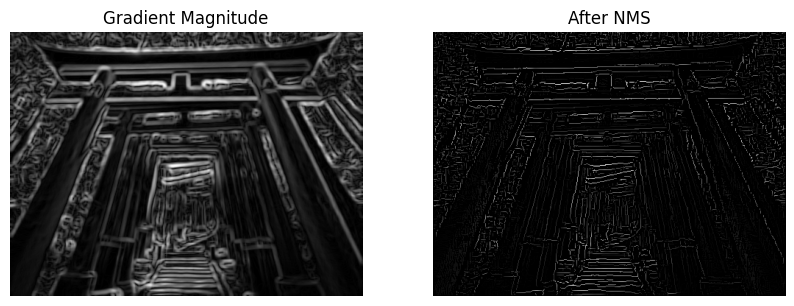

In [25]:
nms = non_max_suppression(mag, direction)
nms_disp = (nms / (nms.max() + 1e-8) * 255).astype(np.uint8)

save_rgb("outputs/torii_step4_nms.png", nms_disp)
show_pair(mag_disp, nms_disp, titles=("Gradient Magnitude", "After NMS"))

#### Double Threshold

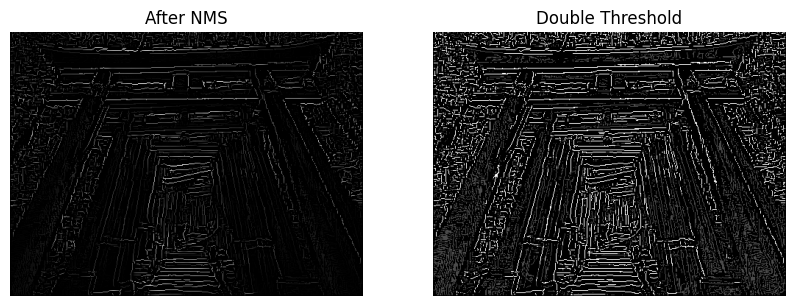

In [26]:
dt, weak_val, strong_val = double_threshold(nms, high_ratio=0.15, low_ratio=0.05)

save_rgb("outputs/torii_step5_double_threshold.png", dt)
show_pair(nms_disp, dt, titles=("After NMS", "Double Threshold"))

#### Hysteresis

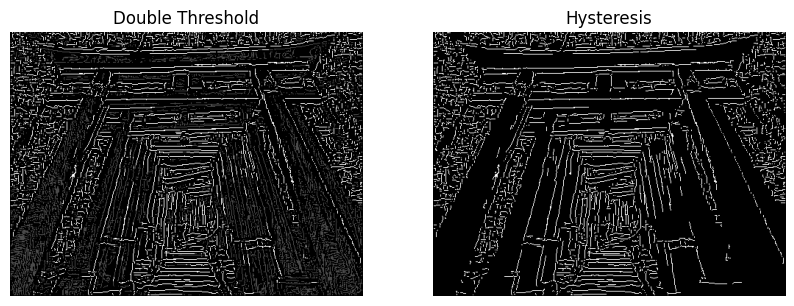

In [27]:
edges = hysteresis(dt, weak_val, strong_val)

save_rgb("outputs/torii_step6_edges.png", edges)
show_pair(dt, edges, titles=("Double Threshold", "Hysteresis"))

#### Full Canny

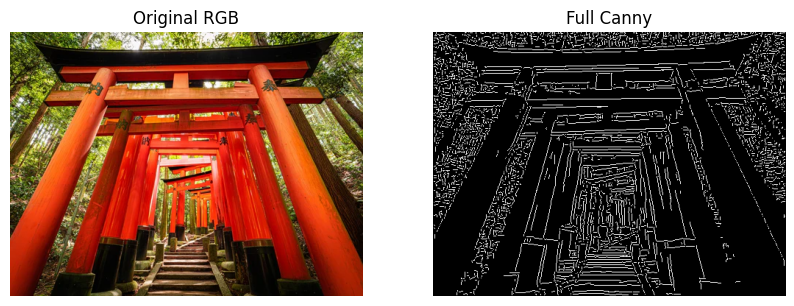

In [28]:
edges2 = canny_manual(img_torii)


save_rgb("outputs/torii_full_edges.png", edges2)
show_pair(img_torii, edges2, titles=("Original RGB", "Full Canny"))

## Day 8

### Discussion

**Choice of methods & parameters**
- Torii gate corridor image chosen to match the goal of extracting clean architectural structure from a cluttered scene.
- Manual Canny pipeline: grayscale → Gaussian blur **(kernel = 5×5, σ = 1.4)** to suppress noise while keeping edges.
- Sobel gradients, non-maximum suppression, and double thresholding **(high = 0.15, low = 0.05)** followed by hysteresis to keep only strong, connected edges.

**Findings & qualitative insights**
- Vertical posts, horizontal beams, and path boundaries become crisp, giving a usable “line drawing” of the corridor.
- The method struggles in low-contrast or shadowed regions, where edges break or disappear.
- Fine textures such as foliage either vanish or appear as scattered speckles, showing the limits of the chosen thresholds.

**Usefulness for the use case**
- Effective for emphasising main architectural geometry as a basis for stylisation or structural analysis.
- Less suitable for images where important information lies in subtle textures or very soft edges.